In [19]:
import xarray as xr
from matplotlib.colors import BoundaryNorm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import os
from utils_ensemble import load_ensemble_tuples

In [3]:
tuples = load_ensemble_tuples()
tuples

,Grain size (um),Rate (kg/m2),Start year,Frequency
0,1,0,-1,-1
1,2,2,2050,1
2,2,2,2049,3
3,2,2,2049,1
4,2,2,2048,3
...,...,...,...,...
2271,100,10,2026,1
2272,100,10,2025,999
2273,100,10,2025,9
2274,100,10,2025,3


In [4]:
os.environ['PROJDIR']


'/gpfs/wolf2/cades/cli185/scratch/ywo'

In [6]:
path_file = os.path.join(os.environ['ZDR'], 'ERW/output/UQ/pft1/r_sequestration_diff.nc')

hr = xr.open_dataset(path_file)

Text(0.5, 1.0, 'CONUS average N2O emission rates for each ensemble member')

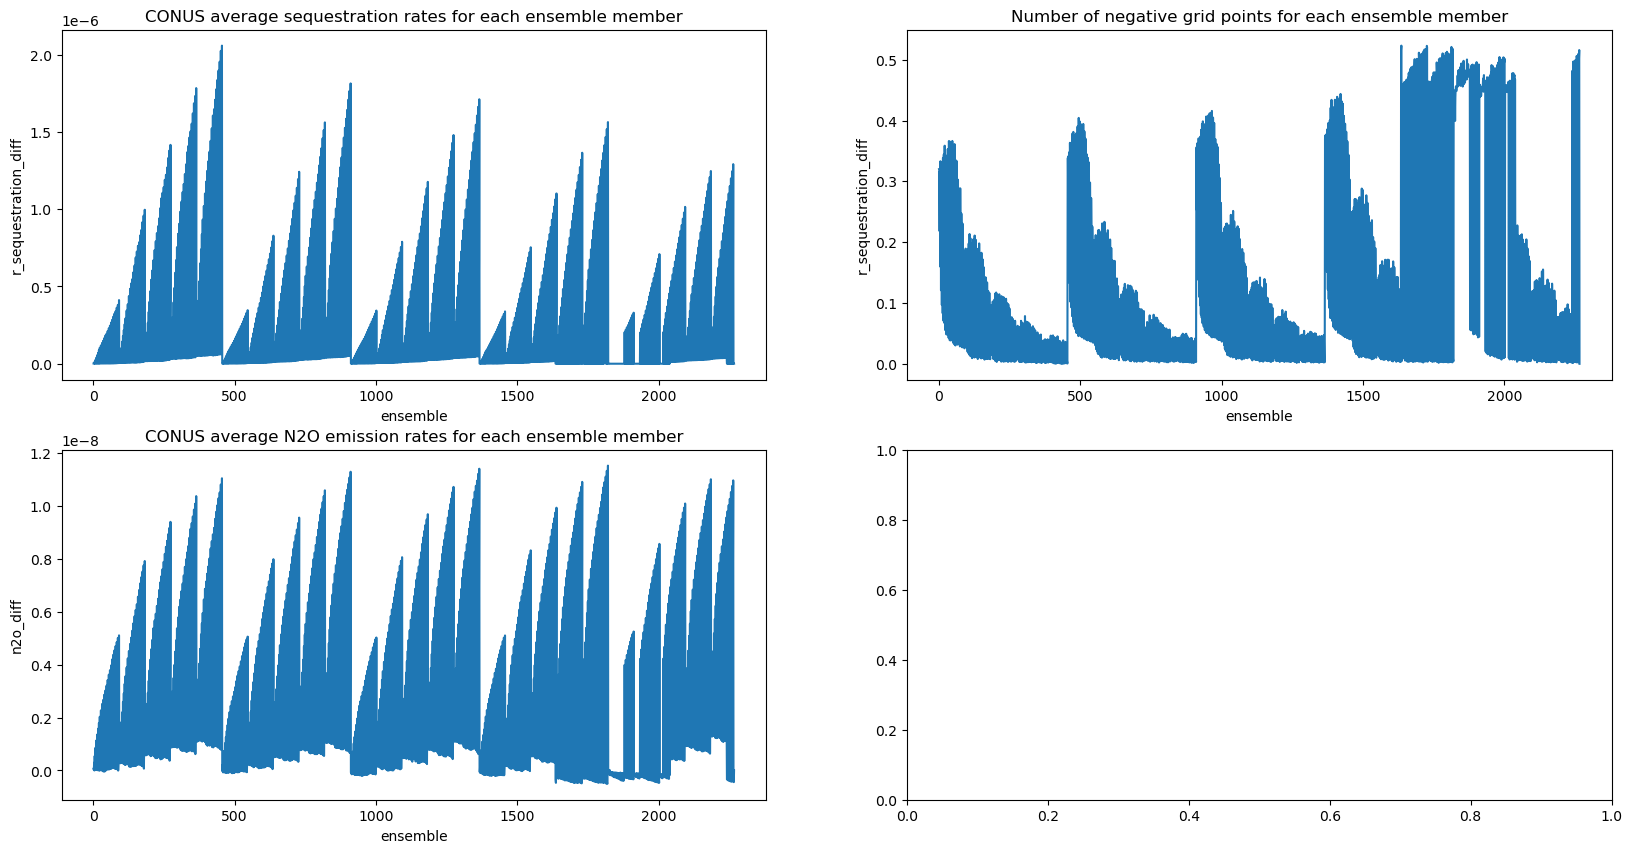

In [7]:
fig, axes = plt.subplots(2, 2, figsize = (20, 10))

ax = axes.flat[0]
hr['r_sequestration_diff'].mean(axis = 2).mean(axis = 1).plot(ax=ax)
ax.set_title('CONUS average sequestration rates for each ensemble member')

ax = axes.flat[1]
(hr['r_sequestration_diff'] < 0).where(~np.isnan(hr['r_sequestration_diff'])
).mean(axis = 2).mean(axis = 1).plot(ax=ax)
ax.set_title('Number of negative grid points for each ensemble member')

ax = axes.flat[2]
(hr['n2o_diff'] * 270).mean(axis = 2).mean(axis = 1).plot(ax=ax)
ax.set_title('CONUS average N2O emission rates for each ensemble member')

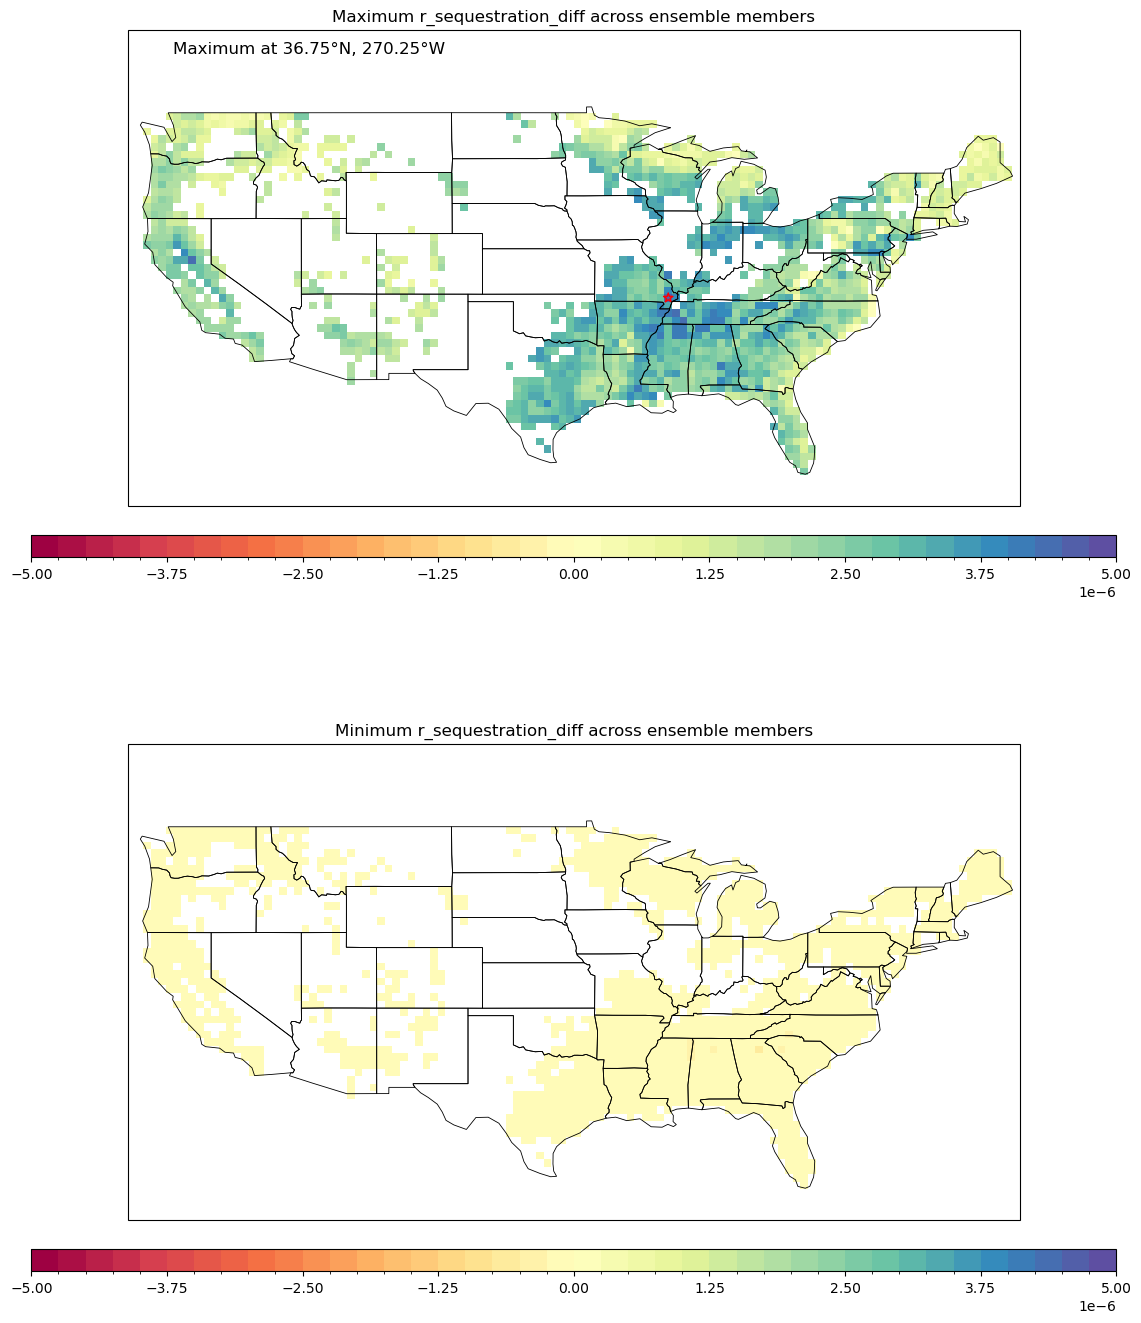

In [37]:
# Plot the spatial map of maximum and minimum r_sequestration_diff
# over all the ensemble members

levels = np.linspace(-5e-6, 5e-6, 41)
norm = BoundaryNorm(boundaries=levels, ncolors=256, clip=True)

fig, axes = plt.subplots(2, 1, figsize=(20, 17), subplot_kw={'projection': ccrs.PlateCarree()})

for ax in axes:
    ax.add_feature(
        cfeature.STATES.with_scale('110m'),
        edgecolor='black',
        linewidth=0.6
    )

ax = axes.flat[0]

spatial_max = hr['r_sequestration_diff'].max(dim='ensemble')
cf = ax.pcolormesh(hr['lon'], hr['lat'], spatial_max, cmap='Spectral', norm=norm)
ax.set_title('Maximum r_sequestration_diff across ensemble members')
plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.05, aspect=50, shrink=0.7)

# Find where the largest sequstration rate occurs
flat  = spatial_max.stack(points=('lat', 'lon'))  # points → 63×118 = 7 434 elements
imax  = flat.argmax('points')            # integer index of the single maximum

lat_max = flat['lat'].isel(points=imax).item()   # float
lon_max = flat['lon'].isel(points=imax).item()   # float

ax.scatter(lon_max, lat_max, color='r', s=50, marker='*', fc = 'none', transform=ccrs.PlateCarree())
ax.text(0.05, 0.95,
        f'Maximum at {lat_max:.2f}°N, {lon_max:.2f}°W',
        color='black', fontsize=12, transform=ax.transAxes)


ax = axes.flat[1]
cf = ax.pcolormesh(hr['lon'], hr['lat'], hr['r_sequestration_diff'].min(dim='ensemble'), 
            cmap='Spectral', norm=norm)
ax.set_title('Minimum r_sequestration_diff across ensemble members')
plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.05, aspect=50, shrink=0.7)

In [42]:
best_spatial_location = hr['r_sequestration_diff'].sel(lat=lat_max, lon=lon_max).values

best_tuple = tuples.iloc[best_spatial_location.argmax()]

print('Best tuple for sequestration rate at maximum location:')
print(best_tuple)

Best tuple for sequestration rate at maximum location:
Grain size (um)       2
Rate (kg/m2)         10
Start year         2025
Frequency             3
Name: 454, dtype: int64
